<a href="https://colab.research.google.com/github/yumi-h-1/Extracting-data-from-web-pages-and-PDFs/blob/main/EMA_data_scraping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Automated EMA & NICE data scraping

Scrapes every medicine in the **latest** CHMP Meeting Highlights news item on the
EMA website, extracts indications with an LLM, and checks each medicine against
NICE.


## Instructions

1. Save a copy of this notebook to your Google Drive before running it.
2. Download the **medicines data table** from
   <https://www.ema.europa.eu/en/medicines/download-medicine-data> (the file is now
   called `medicines-output-medicines-report_en.xlsx`) and put it in the project
   folder on your Drive as `medicines_output_medicines_en.xlsx`. The cell below can
   download it for you instead.
3. Put `therapy_area.xlsx` in the same folder.
4. Download the *procedural steps* PDFs for the medicines listed under the
   extension-of-indication sections of that Meeting Highlights item, and put them
   in an `ema_pdf` folder inside the project folder.
5. Store your OpenAI key as a Colab secret named `OPENAI_API_KEY`.


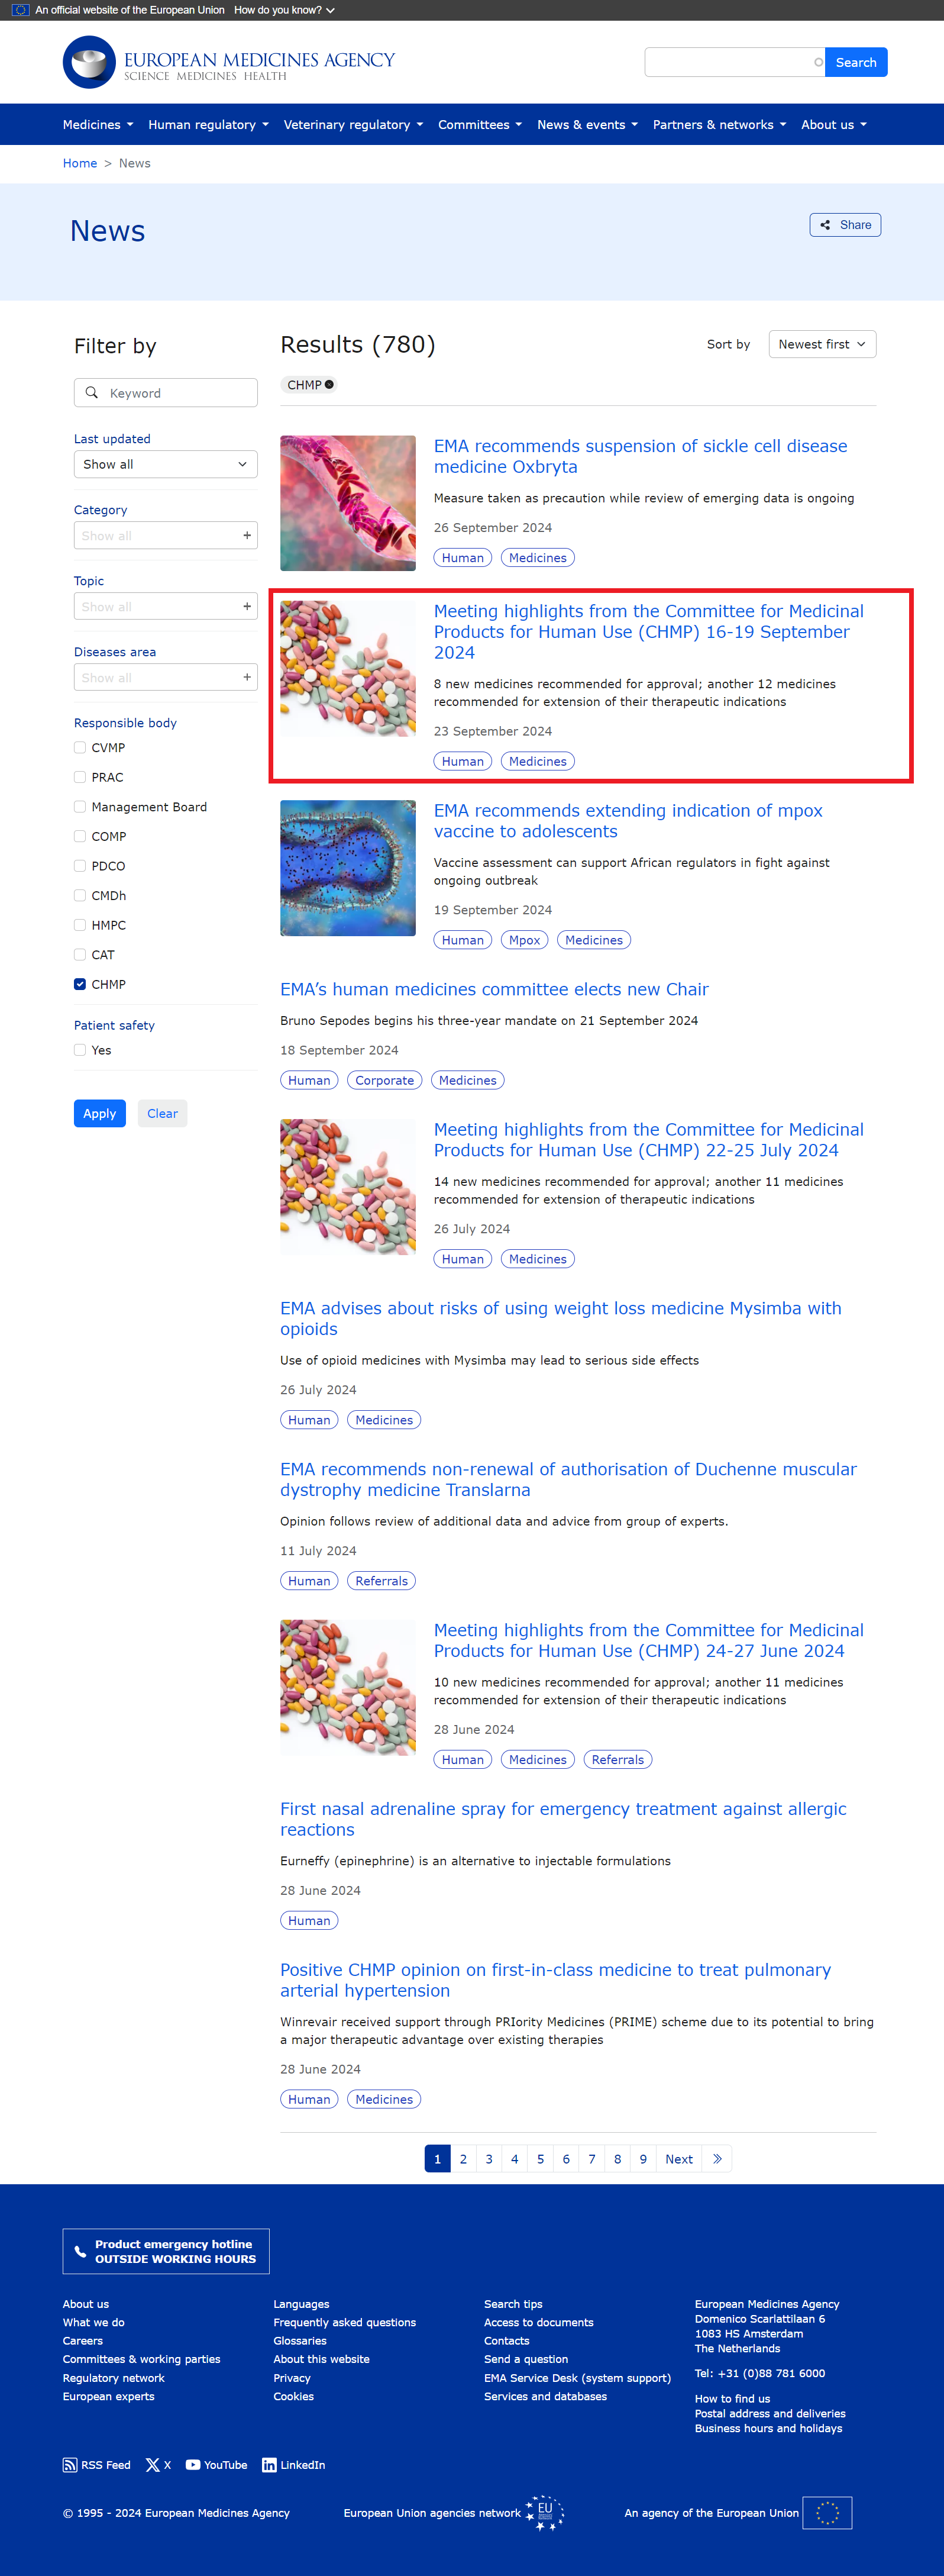

The `ema_pdf` folder and the project folder should look like this:

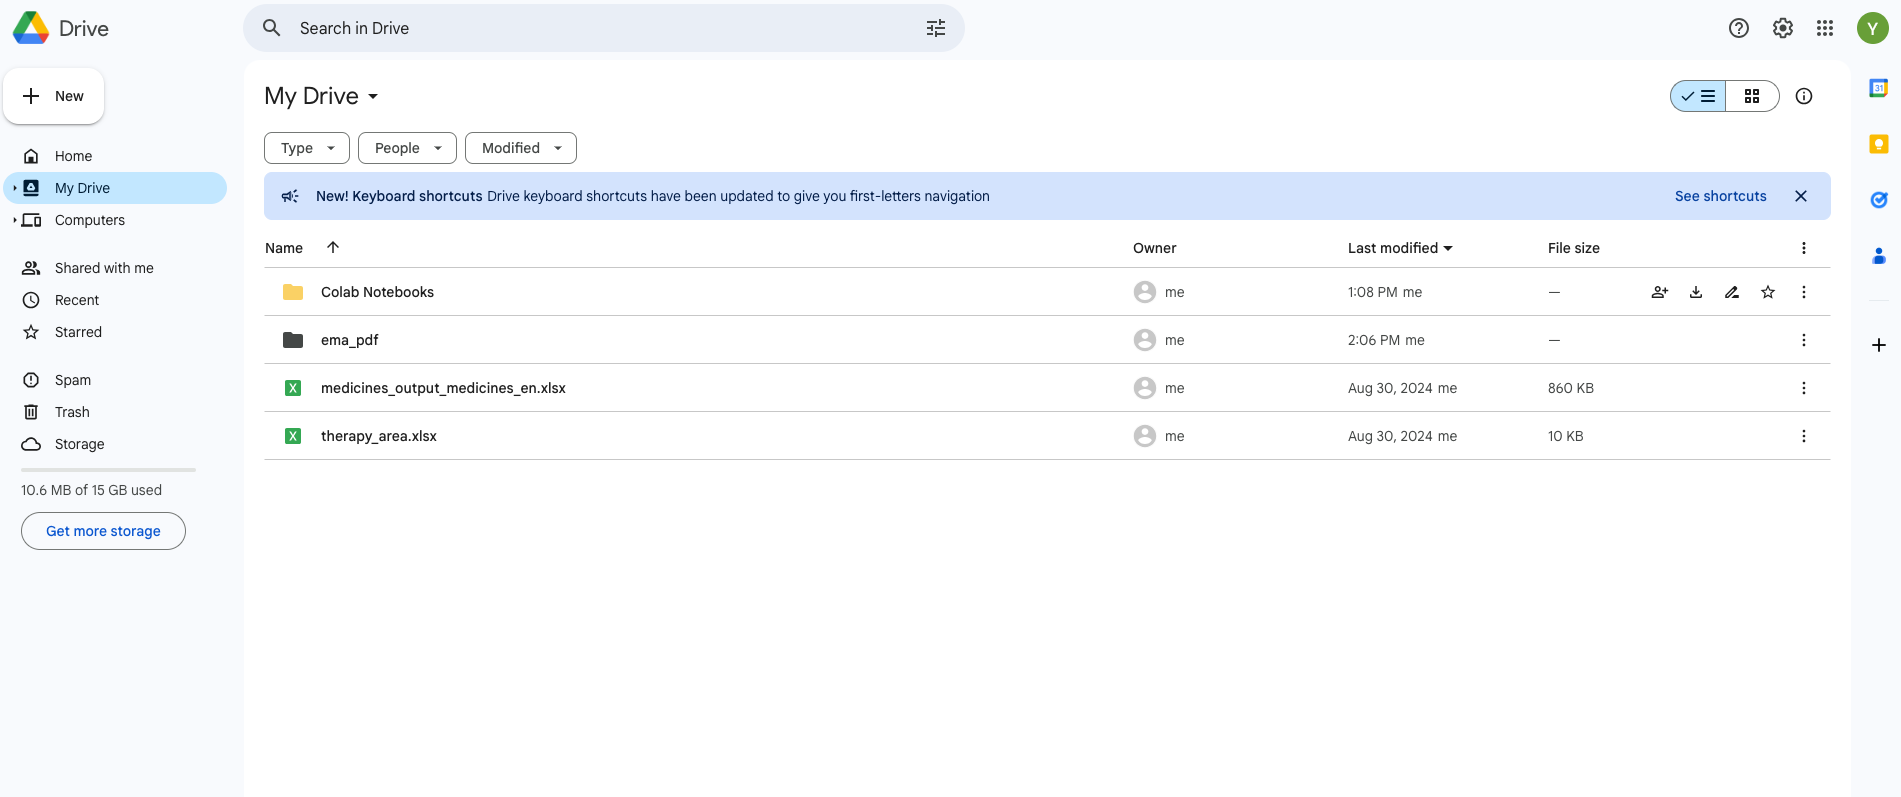

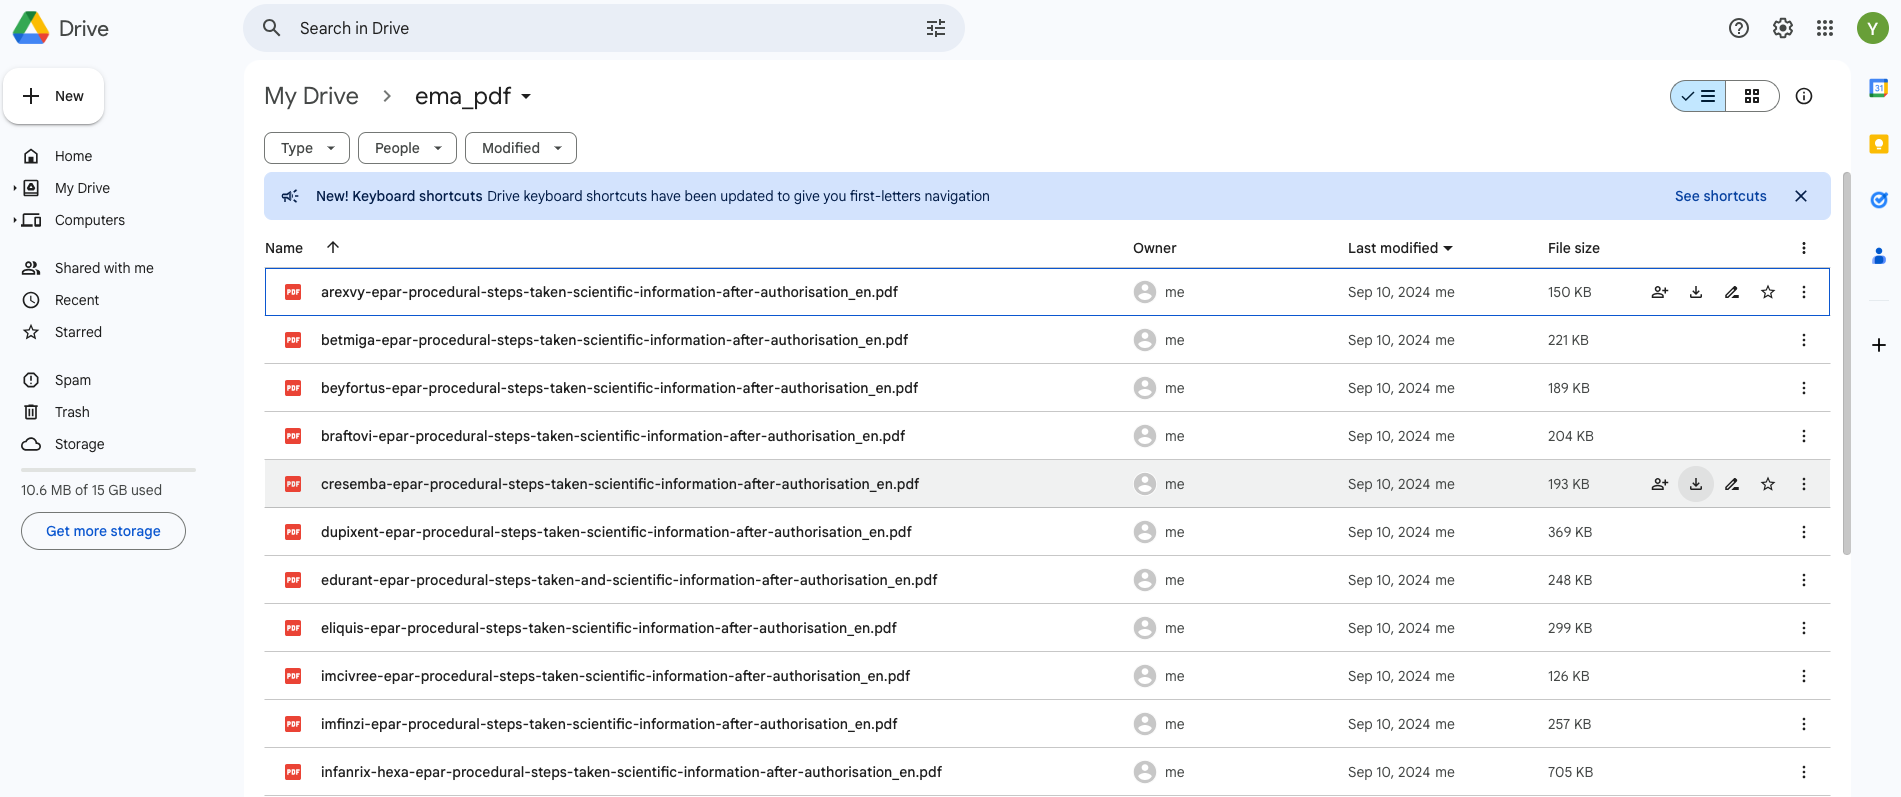

---

# Setup

In [ ]:
!pip install -q openai pypdf beautifulsoup4 pandas openpyxl rouge-score

# Retrieval for the "What changed" summaries. Everything above this line is
# enough for the extraction columns; these four are only needed for summaries.
!pip install -q langchain-text-splitters langchain-openai langchain-chroma chromadb

In [ ]:
import os
import sys

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive, userdata
    drive.mount('/content/drive')
    PROJECT_DIR = '/content/drive/MyDrive/Colab Notebooks/OHE project_Extracting data from web pages and PDFs'
    REPO_DIR = '/content/Automated-EMA-NICE-Data-Scraping'
    if not os.path.exists(REPO_DIR):
        !git clone -q https://github.com/yumi-h-1/Automated-EMA-NICE-Data-Scraping.git {REPO_DIR}
    os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI_API_KEY')
else:
    REPO_DIR = os.path.abspath('..')
    PROJECT_DIR = os.path.join(REPO_DIR, 'data')
    # locally: export OPENAI_API_KEY=... before starting Jupyter (see .env.example)

sys.path.insert(0, os.path.join(REPO_DIR, 'scripts'))
print('scripts:', os.path.join(REPO_DIR, 'scripts'))
print('data   :', PROJECT_DIR)

In [ ]:
import pandas as pd

from build_dataset import build_ema_dataset
from compare_nice_and_indication import compare_nice_and_indication
from summarise import add_summaries
from text_fromNICE import text_fromNICE

# Load the lookup tables

In [ ]:
MEDICINES_XLSX = os.path.join(PROJECT_DIR, 'medicines_output_medicines_en.xlsx')
THERAPY_AREA_XLSX = os.path.join(PROJECT_DIR, 'therapy_area.xlsx')

# Always refresh the EMA medicines table. It changes every week, and a stale copy
# silently produces out-of-date Commission decision dates rather than an error.
EMA_MEDICINES_URL = 'https://www.ema.europa.eu/en/documents/report/medicines-output-medicines-report_en.xlsx'
try:
    import requests
    from config import headers
    response = requests.get(EMA_MEDICINES_URL, headers=headers, timeout=(10, 120))
    response.raise_for_status()
    with open(MEDICINES_XLSX, 'wb') as f:
        f.write(response.content)
    print('Downloaded the current EMA medicines table')
except Exception as e:
    print(f'Could not refresh the EMA table ({e}); using the existing copy')

# The real header row of the EMA export sits on row 9 of the sheet.
df = pd.read_excel(MEDICINES_XLSX, header=8)
df['Name of medicine'] = df['Name of medicine'].str.lower().str.replace(' ', '-')

therapy_area_df = pd.read_excel(THERAPY_AREA_XLSX)
print(f'{len(df)} medicines in the EMA table, {len(therapy_area_df)} therapy areas')

In [ ]:
PDF_DIR = os.path.join(PROJECT_DIR, 'ema_pdf')

pdf_paths = []
if os.path.isdir(PDF_DIR):
    pdf_paths = [os.path.join(PDF_DIR, f) for f in os.listdir(PDF_DIR) if f.endswith('.pdf')]
print(f'{len(pdf_paths)} procedural steps PDFs')

# Build the EMA dataset

One call scrapes the latest Meeting Highlights, follows every EPAR and variation
page, and runs the LLM extractions.

In [ ]:
# `pages` collects the trimmed markup of every page this run fetches, keyed by
# URL. The retrieval step below indexes exactly these, so nothing is downloaded
# a second time.
pages = {}

ema_data_df = build_ema_dataset(pdf_paths, therapy_area_df, df, pages=pages)
ema_data_df.to_csv('EMA_data.csv', index=False)
print(f'{len(pages)} pages kept for retrieval')
ema_data_df.head()

# NICE similarity analysis

In [ ]:
nice_urls = [u for u in ema_data_df['NICE_url'].dropna().unique() if u != 'N/A']
nice_text_dict = text_fromNICE(nice_urls)
print(f'{len(nice_text_dict)} NICE pages fetched')

In [ ]:
comparisons = {
    'Full Indication Similarity': 'Full Indication',
    'New Indication HTML Similarity': 'New indication HTML',
    'New Indication PDF Similarity': 'New indication PDF',
}

for output_column, indication_column in comparisons.items():
    results = compare_nice_and_indication(
        nice_text_dict, ema_data_df[[indication_column, 'NICE_url']]
    )
    lookup = {r['NICE_url']: r['Result'] for r in results}
    ema_data_df[output_column] = ema_data_df['NICE_url'].map(lookup).fillna('N/A')

ema_data_df.head()

# Plain-English summary of what changed

EMA marks an indication change as a character-level diff, so `New indication HTML`
and `Removed indication HTML` come back as fragments — `"A"`, `"-based regimen"`,
`"an"`. They are accurate and nearly unreadable.

This step turns them back into a sentence. It is the only step in the notebook
that uses retrieval: the extraction prompts get the page they need, but a summary
has to read across a whole EPAR, the variation diff *and* the NICE result, which
does not fit in one prompt. So the pages are chunked, embedded into Chroma via
LangChain, and only the passages retrieved for that medicine go into the prompt —
numbered, so the model can cite which one each sentence came from.

`rag.to_markers` rewrites EMA's bold and strikethrough into literal `[ADDED]` and
`[REMOVED]` markers before chunking. Without that the formatting is lost in the
plain text, and the retriever cannot tell a new indication from the paragraph
around it — which is what went wrong in the first attempt at this, in
`(Llama3_1)Experiment_Ollama_+_Langchain__etc.ipynb`.

In [ ]:
# `retrieval_log` keeps the passages each summary was given, so the checks in the
# next cell can score the retrieval as well as the summary.
retrieval_log = {}

add_summaries(ema_data_df, pages, nice_text_dict, retrieval_log=retrieval_log)
ema_data_df[['Product Name', 'What changed', 'Summary sources']].head(10)

### Did the summaries stay on the sources?

Three checks, none of which needs a labelled answer. EMA's own bold markup is the
ground truth for what changed, so a search that missed it has failed no matter how
the sentence reads.

In [ ]:
import sys, os
sys.path.insert(0, os.path.join(REPO_DIR, 'evaluation'))

from grounding import check_retrieval, check_summaries, mean_recall

retrieval = check_retrieval(ema_data_df, retrieval_log, pages)
recall = mean_recall(retrieval)
print(f'Retrieval recall: {recall:.2f} over {len(retrieval)} medicines with a marked-up change'
      if recall is not None else 'No medicine at this meeting had a marked-up change')
for finding in retrieval:
    if finding['recall'] < 1.0:
        print(f"  missed {finding['Product Name']}: "
              f"{finding['retrieved']}/{finding['expected']} {finding['missed']}")

summaries = check_summaries(ema_data_df, retrieval_log)
print(f'\n{len(summaries)} summaries checked')
for finding in summaries:
    if finding['verdict'] != 'grounded':
        print(f"  {finding['verdict']:<11} {finding['Product Name']:<22} "
              f"supported={finding['supported_fraction']:.2f} "
              f"cited={finding['citation_rate']:.2f}")
        print(f"    {finding['detail']}")

# What comes out

One row per medicine recommended at the **most recent** CHMP meeting, with 26
columns — 28 once the summary step above has run. `ema_data_df` is that table;
the cell below summarises the run.

### Where each column comes from

| Group | Columns | Source |
|---|---|---|
| **Identification** | `Product Name`, `INN`, `Marketing authorisation holder`, `epar_url`, `variation_url`, `MH_url` | The Meeting Highlights news page |
| **Clinical** | `Full Indication`, `New indication HTML`, `Removed indication HTML`, `New indication PDF` | Extracted by the LLM from the EPAR page, the variation page and the procedural steps PDF |
| **Classification** | `Therapy class`, `Therapy Area`, `Cancer`, `Orphan` | ATC code on the EPAR page, mapped through `therapy_area.xlsx` |
| **Dates** | `CHMP Opinion Date`, `Decision date`, `EMA date for extension` | News title, EMA medicines table, and the PDF |
| **NICE** | `Search Result in NICE`, `NICE_url`, and the three `... Similarity` columns | NICE search page |
| **Summary** | `What changed`, `Summary sources` | Written by the LLM from passages retrieved out of the pages above |

### When `N/A` is normal, and when it is a problem

`N/A` is **expected** for:

- `Therapy class` / `Therapy Area` on a brand-new medicine — EMA does not assign an
  ATC code until the Commission decision.
- `Decision date` / `Orphan` on a brand-new medicine — it is not in the EMA
  medicines table yet.
- `New indication PDF` / `EMA date for extension` when you did not download that
  medicine's procedural steps PDF, or the medicine is a first authorisation.
- Every NICE column when NICE has no result for that INN — common for medicines
  the EU approves first.

`N/A` is a **problem** when `Full Indication`, `INN` or
`Marketing authorisation holder` is empty. That usually means EMA changed their
page layout. Run `pytest tests/` to find out which part broke.

### Two things to read critically

- `New indication HTML` and `Removed indication HTML` come from EMA's **bold and
  strikethrough markup**, which is a character-level diff. Fragments like `"A"` or
  `"-based regimen"` are what the page actually marks up, not an extraction error.
  `What changed` is what turns them back into a sentence — and unlike them, it is
  written rather than copied, so read it against the `[S#]` passages it cites.
- The NICE similarity columns compare against the NICE **search results page**, not
  the full guidance document, so read them as "does a NICE result look related",
  not "NICE has appraised this indication".

In [ ]:
total = len(ema_data_df)
print(f'{total} medicines from: {ema_data_df["title"].iloc[0]}')
print(f'  {(ema_data_df["Initial Approval"] == "Initial approval").sum()} new medicines, '
      f'{(ema_data_df["Initial Approval"] == "Extension").sum()} extensions of indication')
print(f'  {(ema_data_df["Cancer"] == "Yes").sum()} oncology, '
      f'{(ema_data_df["Orphan"] == "Yes").sum()} orphan')

print('\nHow complete is each column?')
for column in ['Full Indication', 'New indication HTML', 'New indication PDF',
               'Therapy Area', 'Decision date', 'Search Result in NICE']:
    filled = (ema_data_df[column].astype(str) != 'N/A').sum()
    print(f'  {column:<24} {filled:>3}/{total}')

# Columns that should never be empty; anything here means the scraper is broken.
for column in ['Product Name', 'INN', 'Marketing authorisation holder', 'Full Indication']:
    missing = ema_data_df.loc[ema_data_df[column].astype(str) == 'N/A', 'Product Name'].tolist()
    if missing:
        print(f'\nWARNING: {column} is missing for {missing} - check the EMA page layout')

# Save the results

In [ ]:
ema_data_df.to_excel('final_EMA_dataset.xlsx', index=False)
print('Saved final_EMA_dataset.xlsx with', len(ema_data_df), 'medicines')

---

## Checking the run

No hand-labelled answers are needed for either of these:

```bash
pytest tests/                                        # did EMA change their HTML?
python evaluation/cross_check.py final_EMA_dataset.xlsx   # do the dates match EMA's own tables?
```

`evaluation/grounding.py` additionally checks that every extracted indication is
text that actually appears on the source page, which is how invented answers are
caught without a reference dataset.